In [6]:
import pandas as pd

df = pd.read_csv("/Users/1kc/Desktop/criteo-uplift-project/data/criteo-uplift-v2.1.csv", low_memory=False)
df.shape

(13979592, 16)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [c for c in df.columns if c.startswith("f")]

In [8]:
visit_rate = df.groupby("treatment")["visit"].mean()
conv_rate = df.groupby("treatment")["conversion"].mean()
conv_given_visit = df[df["visit"] == 1].groupby("treatment")["conversion"].mean()

ate_visit = visit_rate[1] - visit_rate[0]
ate_conv = conv_rate[1] - conv_rate[0]
ate_conv_given_visit = conv_given_visit[1] - conv_given_visit[0]

print("Visit rate (C, T):", visit_rate[0], visit_rate[1])
print("Conversion rate (C, T):", conv_rate[0], conv_rate[1])
print("Conversion|Visit (C, T):", conv_given_visit[0], conv_given_visit[1])
print("\nATE Visit:", ate_visit, f"({ate_visit*100:.3f} pp)")
print("ATE Conversion:", ate_conv, f"({ate_conv*100:.3f} pp)")
print("ATE Conversion|Visit:", ate_conv_given_visit, f"({ate_conv_given_visit*100:.3f} pp)")

Visit rate (C, T): 0.03820095691954503 0.048543360048743316
Conversion rate (C, T): 0.0019375880152813366 0.0030894610674129645
Conversion|Visit (C, T): 0.05072092878097497 0.06364332968115058

ATE Visit: 0.010342403129198284 (1.034 pp)
ATE Conversion: 0.0011518730521316279 (0.115 pp)
ATE Conversion|Visit: 0.012922400900175608 (1.292 pp)


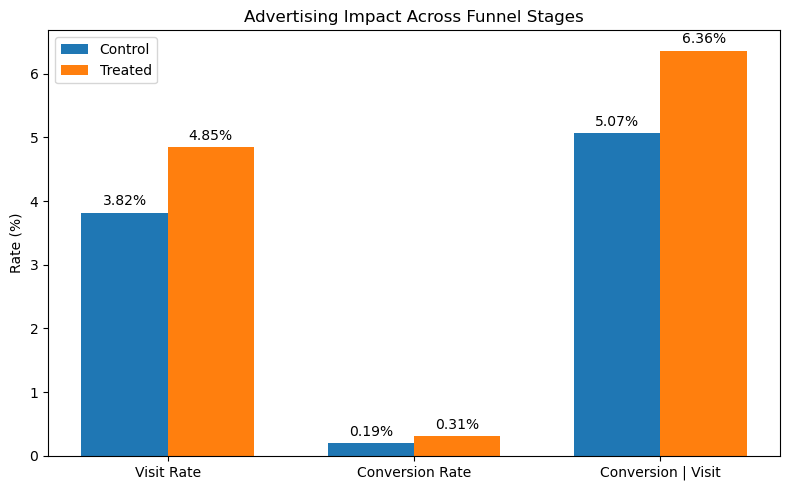

In [9]:
labels = ["Visit Rate", "Conversion Rate", "Conversion | Visit"]
control_vals = [visit_rate[0]*100, conv_rate[0]*100, conv_given_visit[0]*100]
treated_vals = [visit_rate[1]*100, conv_rate[1]*100, conv_given_visit[1]*100]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x - width/2, control_vals, width, label="Control")
b2 = ax.bar(x + width/2, treated_vals, width, label="Treated")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Rate (%)")
ax.set_title("Advertising Impact Across Funnel Stages")
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}%", (bar.get_x()+bar.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", va="bottom")

plt.tight_layout()
plt.show()

/var/folders/7p/3cy1rvhd41bgvd71587cj0z40000gn/T/ipykernel_40692/1923240941.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  realized_uplift = out.groupby("decile").apply(


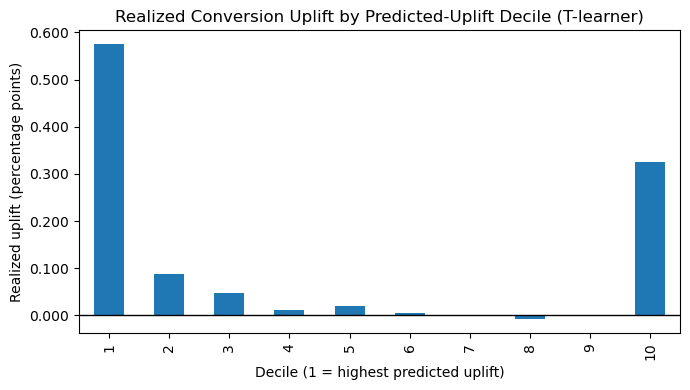

Realized uplift by decile (percentage points):
decile
1     0.575
2     0.087
3     0.048
4     0.011
5     0.019
6     0.006
7     0.000
8    -0.008
9     0.002
10    0.325
dtype: float64


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# -------------------------------
# Prepare data
# -------------------------------
feature_cols = [c for c in df.columns if c.startswith("f")]
X = df[feature_cols]
T = df["treatment"].astype(int)
Y = df["conversion"].astype(int)

X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X, T, Y, test_size=0.2, random_state=42, stratify=Y
)

# -------------------------------
# Train T-learner models
# -------------------------------
model_treated = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.1, random_state=42)
model_control = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.1, random_state=42)

model_treated.fit(X_train[T_train == 1], y_train[T_train == 1])
model_control.fit(X_train[T_train == 0], y_train[T_train == 0])

# -------------------------------
# Predict uplift
# -------------------------------
p1 = model_treated.predict_proba(X_test)[:, 1]
p0 = model_control.predict_proba(X_test)[:, 1]
uplift = p1 - p0

# Create output dataframe
out = X_test.copy()
out["treatment"] = T_test.values
out["conversion"] = y_test.values
out["uplift"] = uplift

# Sort by uplift and create deciles
out = out.sort_values("uplift", ascending=False).reset_index(drop=True)

out["decile"] = pd.qcut(np.arange(len(out)), q=10, labels=False) + 1

# Compute realized uplift per decile
realized_uplift = out.groupby("decile").apply(
    lambda g: g.loc[g.treatment == 1, "conversion"].mean() -
              g.loc[g.treatment == 0, "conversion"].mean()
)

# Plot 
plt.figure(figsize=(7,4))
(realized_uplift * 100).plot(kind="bar")

plt.axhline(0, color="black", linewidth=1)

plt.title("Realized Conversion Uplift by Predicted-Uplift Decile (T-learner)")
plt.xlabel("Decile (1 = highest predicted uplift)")
plt.ylabel("Realized uplift (percentage points)")

plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.show()

clean_uplift = (realized_uplift * 100).round(3)

print("Realized uplift by decile (percentage points):")
print(clean_uplift)

In [13]:
import numpy as np
import pandas as pd

def qini_table(df_ranked, score_col="uplift", t_col="treatment", y_col="conversion", n_bins=10):
    d = df_ranked[[score_col, t_col, y_col]].dropna().copy()
    d = d.sort_values(score_col, ascending=False).reset_index(drop=True)

    # cumulative bins (top 10%, 20%, ..., 100%)
    d["bin"] = pd.qcut(np.arange(len(d)), q=n_bins, labels=False) + 1

    rows = []
    for b in range(1, n_bins+1):
        g = d[d["bin"] <= b]  # cumulative top bins

        nt = (g[t_col] == 1).sum()
        nc = (g[t_col] == 0).sum()
        yt = g.loc[g[t_col] == 1, y_col].sum()
        yc = g.loc[g[t_col] == 0, y_col].sum()

        inc = np.nan
        if nc > 0:
            inc = yt - (nt / nc) * yc   # incremental conversions (scaled control)

        top_pct = int(b * (100 / n_bins))
        rows.append({"Top % targeted": top_pct, "Cumulative incremental conversions": inc})

    tab = pd.DataFrame(rows)
    final_inc = tab["Cumulative incremental conversions"].iloc[-1]
    tab["Random baseline"] = (tab["Top % targeted"]/100.0) * final_inc
    tab["Qini (over random)"] = tab["Cumulative incremental conversions"] - tab["Random baseline"]
    return tab

qini_tbl = qini_table(out, n_bins=10)
qini_tbl

,Top % targeted,Cumulative incremental conversions,Random baseline,Qini (over random)
0,10,1389.959644,277.110018,1112.849626
1,20,1709.689846,554.220035,1155.469811
2,30,1880.994701,831.330053,1049.664648
3,40,1941.283431,1108.440070,832.843361
4,50,1999.245247,1385.550088,613.695159
5,60,1994.836624,1662.660105,332.176519
6,70,1998.086205,1939.770123,58.316082
7,80,2003.239873,2216.880140,-213.640267
8,90,2013.991721,2493.990158,-479.998437
9,100,2771.100175,2771.100175,0.000000


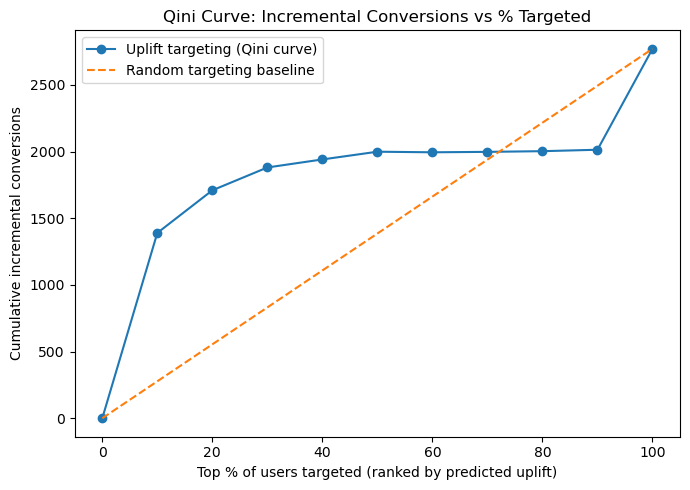

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot([0]+qini_tbl["Top % targeted"].tolist(),
         [0]+qini_tbl["Cumulative incremental conversions"].tolist(),
         marker="o", label="Uplift targeting (Qini curve)")

plt.plot([0]+qini_tbl["Top % targeted"].tolist(),
         [0]+qini_tbl["Random baseline"].tolist(),
         linestyle="--", label="Random targeting baseline")

plt.title("Qini Curve: Incremental Conversions vs % Targeted")
plt.xlabel("Top % of users targeted (ranked by predicted uplift)")
plt.ylabel("Cumulative incremental conversions")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
def incremental_conversions_topk(df_ranked, k_pct):
    d = df_ranked.sort_values("uplift", ascending=False).reset_index(drop=True)
    k = int(len(d) * (k_pct / 100.0))
    g = d.iloc[:k].copy()

    nt = (g["treatment"] == 1).sum()
    nc = (g["treatment"] == 0).sum()
    yt = g.loc[g["treatment"] == 1, "conversion"].sum()
    yc = g.loc[g["treatment"] == 0, "conversion"].sum()

    if nc == 0:
        return np.nan
    return yt - (nt / nc) * yc

rows = []
for k in [5, 10, 20, 30, 50, 100]:
    rows.append({
        "Policy": f"Target top {k}%",
        "Estimated incremental conversions": incremental_conversions_topk(out, k)
    })

rows.append({"Policy": "Treat-none (0%)", "Estimated incremental conversions": 0.0})

policy_df = pd.DataFrame(rows)
policy_df

,Policy,Estimated incremental conversions
0,Target top 5%,1098.016675
1,Target top 10%,1389.970807
2,Target top 20%,1709.653564
3,Target top 30%,1880.998900
4,Target top 50%,1999.247805
5,Target top 100%,2771.100175
6,Treat-none (0%),0.000000


In [16]:
# qini_tbl already computed
best_qini_row = qini_tbl.loc[qini_tbl["Qini (over random)"].idxmax()]
best_qini_row

Top % targeted                          20.000000
Cumulative incremental conversions    1709.689846
Random baseline                        554.220035
Qini (over random)                    1155.469811
Name: 1, dtype: float64

In [17]:
policy_df2 = policy_df.copy()

# extract numeric k from "Target top X%" strings
policy_df2["k_pct"] = policy_df2["Policy"].str.extract(r"(\d+)").astype(float)

policy_df2["inc_per_1pct"] = policy_df2["Estimated incremental conversions"] / policy_df2["k_pct"]
policy_df2 = policy_df2.sort_values("k_pct")

policy_df2[["Policy","Estimated incremental conversions","inc_per_1pct"]]

,Policy,Estimated incremental conversions,inc_per_1pct
6,Treat-none (0%),0.000000,NaN
0,Target top 5%,1098.016675,219.603335
1,Target top 10%,1389.970807,138.997081
2,Target top 20%,1709.653564,85.482678
3,Target top 30%,1880.998900,62.699963
4,Target top 50%,1999.247805,39.984956
5,Target top 100%,2771.100175,27.711002


In [18]:
policy_df3 = policy_df2.sort_values("k_pct").copy()
policy_df3["marginal_gain"] = policy_df3["Estimated incremental conversions"].diff()
policy_df3["delta_k"] = policy_df3["k_pct"].diff()
policy_df3["marginal_per_1pct"] = policy_df3["marginal_gain"] / policy_df3["delta_k"]

policy_df3[["Policy","Estimated incremental conversions","marginal_per_1pct"]]

,Policy,Estimated incremental conversions,marginal_per_1pct
6,Treat-none (0%),0.000000,NaN
0,Target top 5%,1098.016675,219.603335
1,Target top 10%,1389.970807,58.390826
2,Target top 20%,1709.653564,31.968276
3,Target top 30%,1880.998900,17.134534
4,Target top 50%,1999.247805,5.912445
5,Target top 100%,2771.100175,15.437047


In [19]:
treat_all = policy_df2.loc[policy_df2["k_pct"]==100, "Estimated incremental conversions"].iloc[0]

for k in [10, 20, 30]:
    inc = policy_df2.loc[policy_df2["k_pct"]==k, "Estimated incremental conversions"].iloc[0]
    frac = inc / treat_all
    print(f"Top {k}%: {inc:.1f} incremental conversions = {frac:.1%} of treat-all")

Top 10%: 1390.0 incremental conversions = 50.2% of treat-all
Top 20%: 1709.7 incremental conversions = 61.7% of treat-all
Top 30%: 1881.0 incremental conversions = 67.9% of treat-all


In [ ]:
import os
os.makedirs("precomputed", exist_ok=True)

# ── Hypothesis 1: Funnel rates ────────────────────────────────────
visit_rate.to_csv("precomputed/visit_rate.csv")
conv_rate.to_csv("precomputed/conversion_rate.csv")
conv_given_visit.to_csv("precomputed/conv_given_visit.csv")

# ── Hypothesis 2: Uplift by decile ───────────────────────────────
# 'out' is the df with uplift scores from the T-learner (Cell 4)
out["decile"] = pd.qcut(out["uplift"].rank(method="first"), q=10, labels=False) + 1
decile_uplift = (
    out.groupby("decile").apply(
        lambda g: (
            g.loc[g["treatment"]==1, "conversion"].mean() -
            g.loc[g["treatment"]==0, "conversion"].mean()
        ) * 100
    )
    .sort_index(ascending=False)
    .reset_index()
)
decile_uplift.columns = ["decile", "uplift_pp"]
decile_uplift.to_csv("precomputed/decile_uplift.csv", index=False)

# ── Hypothesis 3: Qini table & policy table ───────────────────────
qini_tbl.to_csv("precomputed/qini_table.csv", index=False)
policy_df.to_csv("precomputed/policy_table.csv", index=False)

print("Saved precomputed files:")
for f in os.listdir("precomputed"):
    size = os.path.getsize(f"precomputed/{f}")
    print(f"  precomputed/{f}  ({size} bytes)")